In [ ]:
import os
import sys
import math
import time
import json
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision.transforms import functional as TF
from sklearn.cluster import KMeans

print(f"Python version : {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device    : {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    print("WARNING: CUDA GPU is not enabled. In Colab, go to Runtime -> Change runtime type -> GPU.")
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True


Python version : 3.12.13
PyTorch version: 2.10.0+cu128
CUDA available : True
CUDA device    : Tesla T4


In [ ]:
@dataclass
class CFG:
    seed: int = 42
    data_root: str = './data'
    work_dir: str = './assignment3_outputs'
    batch_size: int = 100
    num_workers: int = 2 if os.name != 'nt' else 0
    pin_memory: bool = True

    regression_epoch_variants: Tuple[int, ...] = (5, 10, 20)
    classification_epochs: int = 20
    unet_epochs: int = 20

    lr: float = 1e-3
    weight_decay: float = 1e-5

    encoder_channels: Tuple[int, int, int] = (64, 128, 256)
    decoder_channels: Tuple[int, int] = (128, 64)
    kernel_size: int = 3

    num_vis_samples: int = 8
    activation_maps_to_show: int = 8

    num_color_bins: int = 24
    kmeans_sample_pixels: int = 200_000

    save_checkpoints: bool = True
    output_limit_images: int = 12

cfg = CFG()
Path(cfg.work_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.work_dir, 'checkpoints').mkdir(parents=True, exist_ok=True)
Path(cfg.work_dir, 'figures').mkdir(parents=True, exist_ok=True)

print(asdict(cfg))


{'seed': 42, 'data_root': './data', 'work_dir': './assignment3_outputs', 'batch_size': 100, 'num_workers': 2, 'pin_memory': True, 'regression_epoch_variants': (5, 10, 20), 'classification_epochs': 20, 'unet_epochs': 20, 'lr': 0.001, 'weight_decay': 1e-05, 'encoder_channels': (64, 128, 256), 'decoder_channels': (128, 64), 'kernel_size': 3, 'num_vis_samples': 8, 'activation_maps_to_show': 8, 'num_color_bins': 24, 'kmeans_sample_pixels': 200000, 'save_checkpoints': True, 'output_limit_images': 12}


In [ ]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(cfg.seed)
print('Seed set to', cfg.seed)


Seed set to 42


- downloads **CIFAR-10**,
- filters only the **Horse** class,
- builds grayscale inputs and RGB targets,
- prepares 24-bin color labels for the classification models,
- splits the horse training set into **train/validation**,
- keeps the official horse test set as **test**.


In [ ]:

def load_cifar10_horse_tensors(data_root: str):
    train_ds = CIFAR10(root=data_root, train=True, download=True)
    test_ds  = CIFAR10(root=data_root, train=False, download=True)

    if hasattr(train_ds, 'class_to_idx') and 'horse' in train_ds.class_to_idx:
        horse_idx = train_ds.class_to_idx['horse']
    else:
        horse_idx = 7

    train_data = torch.tensor(train_ds.data)
    test_data  = torch.tensor(test_ds.data)
    train_targets = torch.tensor(train_ds.targets)
    test_targets  = torch.tensor(test_ds.targets)

    train_horse = train_data[train_targets == horse_idx]
    test_horse  = test_data[test_targets == horse_idx]

    train_rgb = train_horse.permute(0, 3, 1, 2).float() / 255.0
    test_rgb  = test_horse.permute(0, 3, 1, 2).float() / 255.0

    return train_rgb, test_rgb, horse_idx

train_rgb_all, test_rgb_all, horse_idx = load_cifar10_horse_tensors(cfg.data_root)
print('Horse class index:', horse_idx)
print('Train horse images:', tuple(train_rgb_all.shape))
print('Test horse images :', tuple(test_rgb_all.shape))


Horse class index: 7
Train horse images: (5000, 3, 32, 32)
Test horse images : (1000, 3, 32, 32)


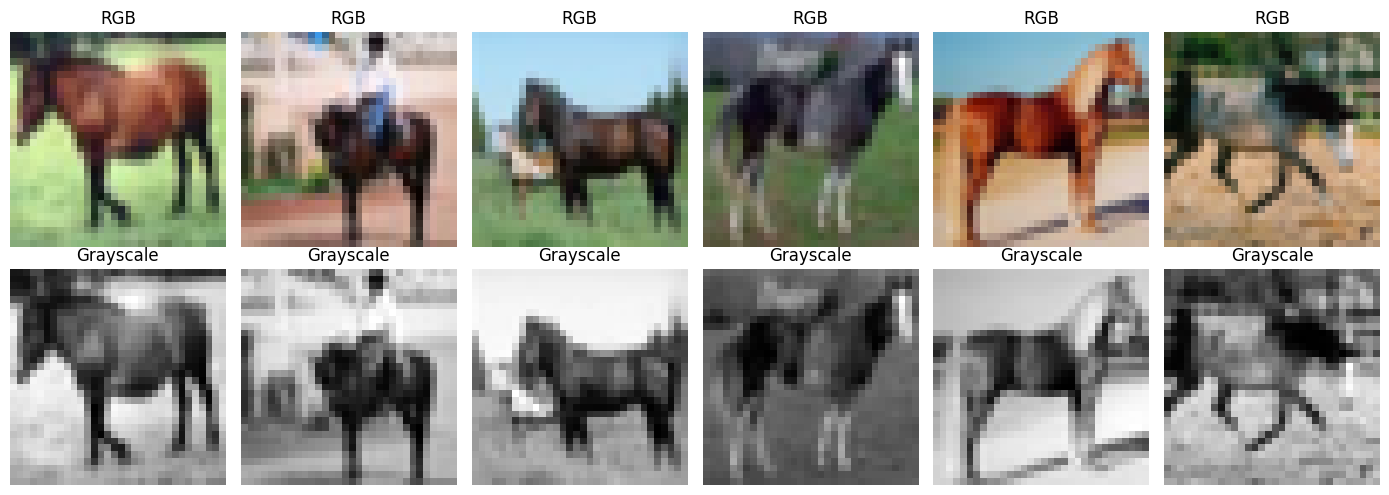

In [ ]:
def rgb_to_gray_batch(x: torch.Tensor) -> torch.Tensor:
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b

train_gray_all = rgb_to_gray_batch(train_rgb_all)
test_gray_all  = rgb_to_gray_batch(test_rgb_all)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(train_rgb_all[i].permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title('RGB')

    axes[1, i].imshow(train_gray_all[i, 0].numpy(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Grayscale')
plt.tight_layout()
plt.show()


In [ ]:
def compute_color_centers(train_rgb: torch.Tensor, n_clusters: int = 24,
                          sample_pixels: int = 200_000) -> torch.Tensor:
    print(f'Computing {n_clusters} KMeans centers from horse training pixels...')
    # Reshape and move to CPU for sklearn KMeans
    pixels = train_rgb.permute(0, 2, 3, 1).reshape(-1, 3).cpu().numpy()

    if len(pixels) > sample_pixels:
        idx = np.random.choice(len(pixels), size=sample_pixels, replace=False)
        pixels = pixels[idx]

    kmeans = KMeans(n_clusters=n_clusters, random_state=cfg.seed, n_init=10)
    kmeans.fit(pixels)

    centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).clamp(0, 1)

    # Save result for later use if needed, but the logic no longer imports it automatically
    np.save('colour_kmeans24_cat7.npy', centers.numpy())
    print('Saved computed centers to colour_kmeans24_cat7.npy')
    return centers

color_centers = compute_color_centers(
    train_rgb_all,
    n_clusters=cfg.num_color_bins,
    sample_pixels=cfg.kmeans_sample_pixels
)

print('Color centers shape:', tuple(color_centers.shape))
print(color_centers[:5])

Computing 24 KMeans centers from horse training pixels...
Saved computed centers to colour_kmeans24_cat7.npy
Color centers shape: (24, 3)
tensor([[0.1470, 0.1272, 0.1094],
        [0.6560, 0.6492, 0.6173],
        [0.3547, 0.3681, 0.2186],
        [0.8518, 0.8669, 0.8755],
        [0.2076, 0.2132, 0.1796]])


In [ ]:
def encode_rgb_to_bins(rgb_batch: torch.Tensor, centers: torch.Tensor) -> torch.Tensor:
    """
    rgb_batch: [N, 3, H, W] in [0,1]
    centers  : [K, 3] in [0,1]
    returns  : [N, H, W] long (nearest center index)
    """
    n, _, h, w = rgb_batch.shape
    pixels = rgb_batch.permute(0, 2, 3, 1).reshape(-1, 3)
    dists = ((pixels[:, None, :] - centers[None, :, :]) ** 2).sum(dim=-1)
    labels = dists.argmin(dim=1).reshape(n, h, w).long()
    return labels

class HorseColorizationDataset(Dataset):
    def __init__(self, gray: torch.Tensor, rgb: torch.Tensor, class_map: torch.Tensor):
        assert gray.ndim == 4 and rgb.ndim == 4 and class_map.ndim == 3
        assert gray.shape[0] == rgb.shape[0] == class_map.shape[0]
        self.gray = gray.float().contiguous()
        self.rgb = rgb.float().contiguous()
        self.class_map = class_map.long().contiguous()

    def __len__(self):
        return self.gray.shape[0]

    def __getitem__(self, idx):
        return {
            'gray': self.gray[idx],            # [1, 32, 32]
            'rgb': self.rgb[idx],              # [3, 32, 32]
            'class_map': self.class_map[idx],  # [32, 32]
        }

train_class_all = encode_rgb_to_bins(train_rgb_all, color_centers)
test_class_all  = encode_rgb_to_bins(test_rgb_all,  color_centers)

g = torch.Generator().manual_seed(cfg.seed)
num_train_total = len(train_rgb_all)
val_size = max(1, int(0.2 * num_train_total))
perm = torch.randperm(num_train_total, generator=g)
val_idx = perm[:val_size]
train_idx = perm[val_size:]

train_ds = HorseColorizationDataset(train_gray_all[train_idx], train_rgb_all[train_idx], train_class_all[train_idx])
val_ds   = HorseColorizationDataset(train_gray_all[val_idx],   train_rgb_all[val_idx],   train_class_all[val_idx])
test_ds  = HorseColorizationDataset(test_gray_all, test_rgb_all, test_class_all)

loader_kwargs = dict(batch_size=cfg.batch_size,
                     num_workers=cfg.num_workers,
                     pin_memory=cfg.pin_memory and device.type == 'cuda')

train_loader = DataLoader(train_ds, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kwargs)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Train: 4000 | Val: 1000 | Test: 1000


1. **RegressionCNN** — predicts continuous **RGB** values per pixel.
2. **PixelClassificationCNN** — predicts one of **24 color bins** per pixel, using the custom **`MyConv2d`** layer.
3. **UNetPixelClassifier** — classification model with **skip connections**.


In [ ]:
class MyConv2d(nn.Module):
    """
    A simple custom Conv2d implementation using unfold + matrix multiplication.
    Supports groups=1 only, which is sufficient for this assignment.
    Fully differentiable and works on CUDA.
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super().__init__()
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        if isinstance(stride, int):
            stride = (stride, stride)
        if isinstance(padding, int):
            padding = (padding, padding)

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        kh, kw = kernel_size
        self.weight = nn.Parameter(torch.empty(out_channels, in_channels, kh, kw))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in = self.in_channels * self.kernel_size[0] * self.kernel_size[1]
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        b, c, h, w = x.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        x_unf = F.unfold(x, kernel_size=(kh, kw), padding=(ph, pw), stride=(sh, sw))  # [B, C*kh*kw, L]
        w_flat = self.weight.view(self.out_channels, -1)                                # [O, C*kh*kw]
        out = torch.einsum('oc,bcl->bol', w_flat, x_unf)                                # [B, O, L]
        if self.bias is not None:
            out = out + self.bias[None, :, None]

        out_h = (h + 2 * ph - kh) // sh + 1
        out_w = (w + 2 * pw - kw) // sw + 1
        out = out.view(b, self.out_channels, out_h, out_w)
        return out


def conv_layer(in_ch, out_ch, kernel_size=3, use_custom=False):
    padding = kernel_size // 2
    if use_custom:
        return MyConv2d(in_ch, out_ch, kernel_size=kernel_size, stride=1, padding=padding, bias=True)
    return nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=1, padding=padding, bias=True)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, use_custom=False, use_bn=True):
        super().__init__()
        layers = [
            conv_layer(in_ch, out_ch, cfg.kernel_size, use_custom=use_custom),
            nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            conv_layer(out_ch, out_ch, cfg.kernel_size, use_custom=use_custom),
            nn.BatchNorm2d(out_ch) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_custom=False):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch, use_custom=use_custom, use_bn=True)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.conv(x)
        return x


In [ ]:
class RegressionCNN(nn.Module):
    """
    Encoder-decoder CNN for direct RGB regression.
    Output is clamped with sigmoid to [0,1].
    """
    def __init__(self):
        super().__init__()
        c1, c2, c3 = cfg.encoder_channels
        d1, d2 = cfg.decoder_channels

        self.enc1 = DoubleConv(1, c1, use_custom=False, use_bn=True)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(c1, c2, use_custom=False, use_bn=True)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(c2, c3, use_custom=False, use_bn=True)
        self.up1 = UpBlock(c3, d1, use_custom=False)
        self.up2 = UpBlock(d1, d2, use_custom=False)
        self.out_conv = nn.Conv2d(d2, 3, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)      # [B, c1, 32, 32]
        x2 = self.pool1(x1)    # [B, c1, 16, 16]
        x3 = self.enc2(x2)     # [B, c2, 16, 16]
        x4 = self.pool2(x3)    # [B, c2,  8,  8]
        x5 = self.bottleneck(x4)
        x6 = self.up1(x5)      # [B, d1, 16, 16]
        x7 = self.up2(x6)      # [B, d2, 32, 32]
        out = torch.sigmoid(self.out_conv(x7))
        return out


In [ ]:
class PixelClassificationCNN(nn.Module):
    def __init__(self, num_bins=24):
        super().__init__()
        c1, c2, c3 = cfg.encoder_channels
        d1, d2 = cfg.decoder_channels

        self.enc1 = DoubleConv(1, c1, use_custom=True, use_bn=True)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(c1, c2, use_custom=True, use_bn=True)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(c2, c3, use_custom=True, use_bn=True)
        self.up1 = UpBlock(c3, d1, use_custom=True)
        self.up2 = UpBlock(d1, d2, use_custom=True)
        self.out_conv = MyConv2d(d2, num_bins, kernel_size=1, stride=1, padding=0, bias=True)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool1(x1)
        x3 = self.enc2(x2)
        x4 = self.pool2(x3)
        x5 = self.bottleneck(x4)
        x6 = self.up1(x5)
        x7 = self.up2(x6)
        logits = self.out_conv(x7)
        return logits


In [ ]:
class UNetPixelClassifier(nn.Module):
    def __init__(self, num_bins=24):
        super().__init__()
        c1, c2, c3 = cfg.encoder_channels
        d1, d2 = cfg.decoder_channels

        self.enc1 = DoubleConv(1, c1, use_custom=True, use_bn=True)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(c1, c2, use_custom=True, use_bn=True)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(c2, c3, use_custom=True, use_bn=True)

        self.up1 = UpBlock(c3, d1, use_custom=True)
        self.fuse1 = DoubleConv(d1 + c2, d1, use_custom=True, use_bn=True)

        self.up2 = UpBlock(d1, d2, use_custom=True)
        self.fuse2 = DoubleConv(d2 + c1 + 1, d2, use_custom=True, use_bn=True)

        self.out_conv = MyConv2d(d2, num_bins, kernel_size=1, stride=1, padding=0, bias=True)

    def forward(self, x):
        x1 = self.enc1(x)          # [B, c1, 32, 32]
        x2 = self.pool1(x1)        # [B, c1, 16, 16]
        x3 = self.enc2(x2)         # [B, c2, 16, 16]
        x4 = self.pool2(x3)        # [B, c2,  8,  8]
        x5 = self.bottleneck(x4)   # [B, c3,  8,  8]

        x6 = self.up1(x5)          # [B, d1, 16, 16]
        x6 = torch.cat([x6, x3], dim=1)
        x6 = self.fuse1(x6)        # [B, d1, 16, 16]

        x7 = self.up2(x6)          # [B, d2, 32, 32]
        x7 = torch.cat([x7, x1, x], dim=1)
        x7 = self.fuse2(x7)        # [B, d2, 32, 32]

        logits = self.out_conv(x7)
        return logits


In [ ]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

x = torch.randn(2, 1, 32, 32)
reg_model = RegressionCNN()
cls_model = PixelClassificationCNN(num_bins=cfg.num_color_bins)
unet_model = UNetPixelClassifier(num_bins=cfg.num_color_bins)

with torch.no_grad():
    y_reg = reg_model(x)
    y_cls = cls_model(x)
    y_unet = unet_model(x)

print('Regression output shape :', tuple(y_reg.shape), '| params:', count_params(reg_model))
print('Classification shape    :', tuple(y_cls.shape), '| params:', count_params(cls_model))
print('UNet shape              :', tuple(y_unet.shape), '| params:', count_params(unet_model))


Regression output shape : (2, 3, 32, 32) | params: 1700355
Classification shape    : (2, 24, 32, 32) | params: 1701720
UNet shape              : (2, 24, 32, 32) | params: 2256408


In [ ]:
# @title

# ===== 14) Plotting / visualization helpers =====
def plot_history(history: Dict[str, List[float]], title: str = 'Training History'):
    keys = list(history.keys())
    fig, axes = plt.subplots(1, len(keys), figsize=(5 * len(keys), 4))
    if len(keys) == 1:
        axes = [axes]
    for ax, k in zip(axes, keys):
        ax.plot(history[k], marker='o')
        ax.set_title(k)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def collect_samples(model: nn.Module, loader: DataLoader, mode: str,
                    centers: Optional[torch.Tensor] = None,
                    max_items: int = 8):
    model.eval()
    samples = []
    for batch in loader:
        gray = batch['gray'].to(device)
        rgb = batch['rgb'].to(device)
        if mode == 'regression':
            pred_rgb = model(gray)
        else:
            logits = model(gray)
            pred_rgb = logits_to_rgb(logits, centers.to(device))

        for i in range(gray.size(0)):
            samples.append((gray[i].cpu(), rgb[i].cpu(), pred_rgb[i].cpu()))
            if len(samples) >= max_items:
                return samples
    return samples


def show_colorization_triplets(samples, title='Colorization Results'):
    n = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, (gray, gt, pred) in enumerate(samples):
        axes[row, 0].imshow(gray[0], cmap='gray')
        axes[row, 0].set_title('Input (Gray)')
        axes[row, 1].imshow(gt.permute(1, 2, 0).clamp(0, 1))
        axes[row, 1].set_title('Ground Truth')
        axes[row, 2].imshow(pred.permute(1, 2, 0).clamp(0, 1))
        axes[row, 2].set_title('Prediction')
        for col in range(3):
            axes[row, col].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
def train_one_model(model, train_loader, val_loader, mode, epochs, device, centers=None, tag='model'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    criterion = nn.MSELoss() if mode == 'regression' else nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            gray = batch['gray'].to(device)
            target = batch['rgb'].to(device) if mode == 'regression' else batch['class_map'].to(device)

            optimizer.zero_grad()
            output = model(gray)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_stats = evaluate_regression(model, val_loader, device) if mode == 'regression' else evaluate_classification(model, val_loader, device, centers)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(val_stats['loss'])
        print(f'Epoch {epoch}/{epochs} | Train Loss: {history["train_loss"][-1]:.4f} | Val Loss: {history["val_loss"][-1]:.4f}')

    return model, history

def evaluate_regression(model, loader, device):
    model.eval()
    criterion = nn.MSELoss()
    losses = []
    with torch.no_grad():
        for batch in loader:
            gray = batch['gray'].to(device)
            rgb = batch['rgb'].to(device)
            output = model(gray)
            losses.append(criterion(output, rgb).item())
    return {'loss': np.mean(losses)}

def logits_to_rgb(logits, centers):
    # logits: [B, K, H, W], centers: [K, 3]
    b, k, h, w = logits.shape
    probs = F.softmax(logits, dim=1) # [B, K, H, W]
    # Weight centers by probabilities
    # Reshape centers to [1, K, 3, 1, 1] and probs to [B, K, 1, H, W]
    rgb = (probs.unsqueeze(2) * centers.view(1, k, 3, 1, 1)).sum(dim=1)
    return rgb

def evaluate_classification(model, loader, device, centers):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    losses = []
    with torch.no_grad():
        for batch in loader:
            gray = batch['gray'].to(device)
            target = batch['class_map'].to(device)
            logits = model(gray)
            losses.append(criterion(logits, target).item())
    return {'loss': np.mean(losses)}

regression_results = {}
for epochs in cfg.regression_epoch_variants:
    print("\n" + '=' * 80)
    print(f'Training RegressionCNN for {epochs} epochs')
    print('=' * 80)
    model = RegressionCNN()
    trained_model, history = train_one_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        mode='regression',
        epochs=epochs,
        device=device,
        centers=None,
        tag=f'regression_{epochs}ep'
    )
    val_stats = evaluate_regression(trained_model, val_loader, device)
    test_stats = evaluate_regression(trained_model, test_loader, device)
    regression_results[epochs] = {
        'model': trained_model,
        'history': history,
        'val_stats': val_stats,
        'test_stats': test_stats,
    }
    print(f'Finished {epochs} epochs | VAL: {val_stats} | TEST: {test_stats}')


Training RegressionCNN for 5 epochs
Epoch 1/5 | Train Loss: 0.0216 | Val Loss: 0.0169
Epoch 2/5 | Train Loss: 0.0118 | Val Loss: 0.0124
Epoch 3/5 | Train Loss: 0.0097 | Val Loss: 0.0093
Epoch 4/5 | Train Loss: 0.0088 | Val Loss: 0.0091
Epoch 5/5 | Train Loss: 0.0077 | Val Loss: 0.0075
Finished 5 epochs | VAL: {'loss': np.float64(0.007548171048983932)} | TEST: {'loss': np.float64(0.007742785383015871)}

Training RegressionCNN for 10 epochs
Epoch 1/10 | Train Loss: 0.0209 | Val Loss: 0.0157
Epoch 2/10 | Train Loss: 0.0117 | Val Loss: 0.0118
Epoch 3/10 | Train Loss: 0.0095 | Val Loss: 0.0097
Epoch 4/10 | Train Loss: 0.0084 | Val Loss: 0.0088
Epoch 5/10 | Train Loss: 0.0077 | Val Loss: 0.0074
Epoch 6/10 | Train Loss: 0.0071 | Val Loss: 0.0072
Epoch 7/10 | Train Loss: 0.0066 | Val Loss: 0.0071
Epoch 8/10 | Train Loss: 0.0063 | Val Loss: 0.0068
Epoch 9/10 | Train Loss: 0.0060 | Val Loss: 0.0072
Epoch 10/10 | Train Loss: 0.0059 | Val Loss: 0.0062
Finished 10 epochs | VAL: {'loss': np.float64

--- RegressionCNN (5 epochs) ---


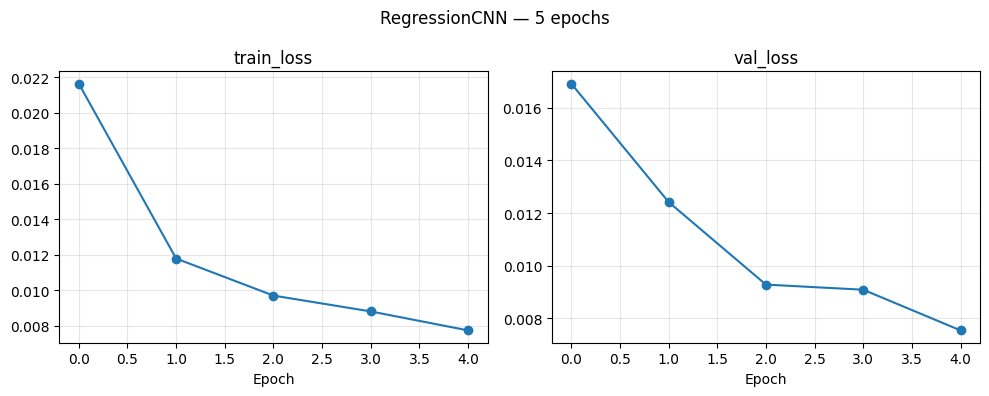

--- RegressionCNN (10 epochs) ---


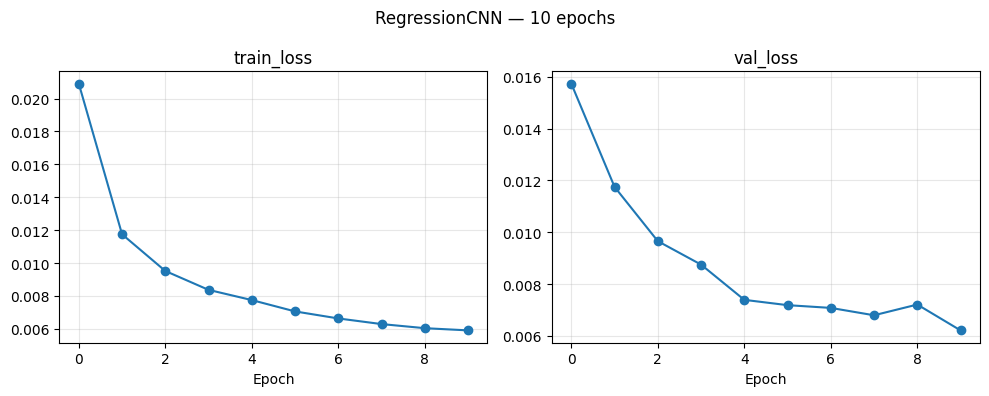

--- RegressionCNN (20 epochs) ---


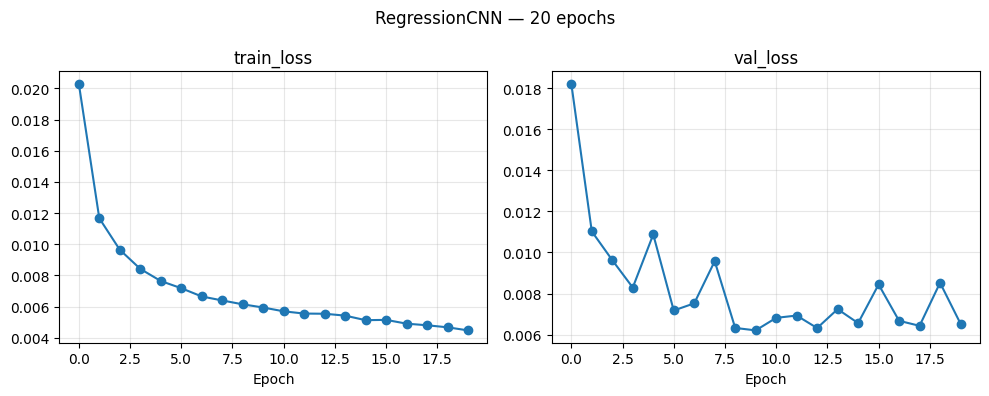

In [ ]:
for epochs, result in regression_results.items():
    print(f'--- RegressionCNN ({epochs} epochs) ---')
    plot_history(result['history'], title=f'RegressionCNN — {epochs} epochs')


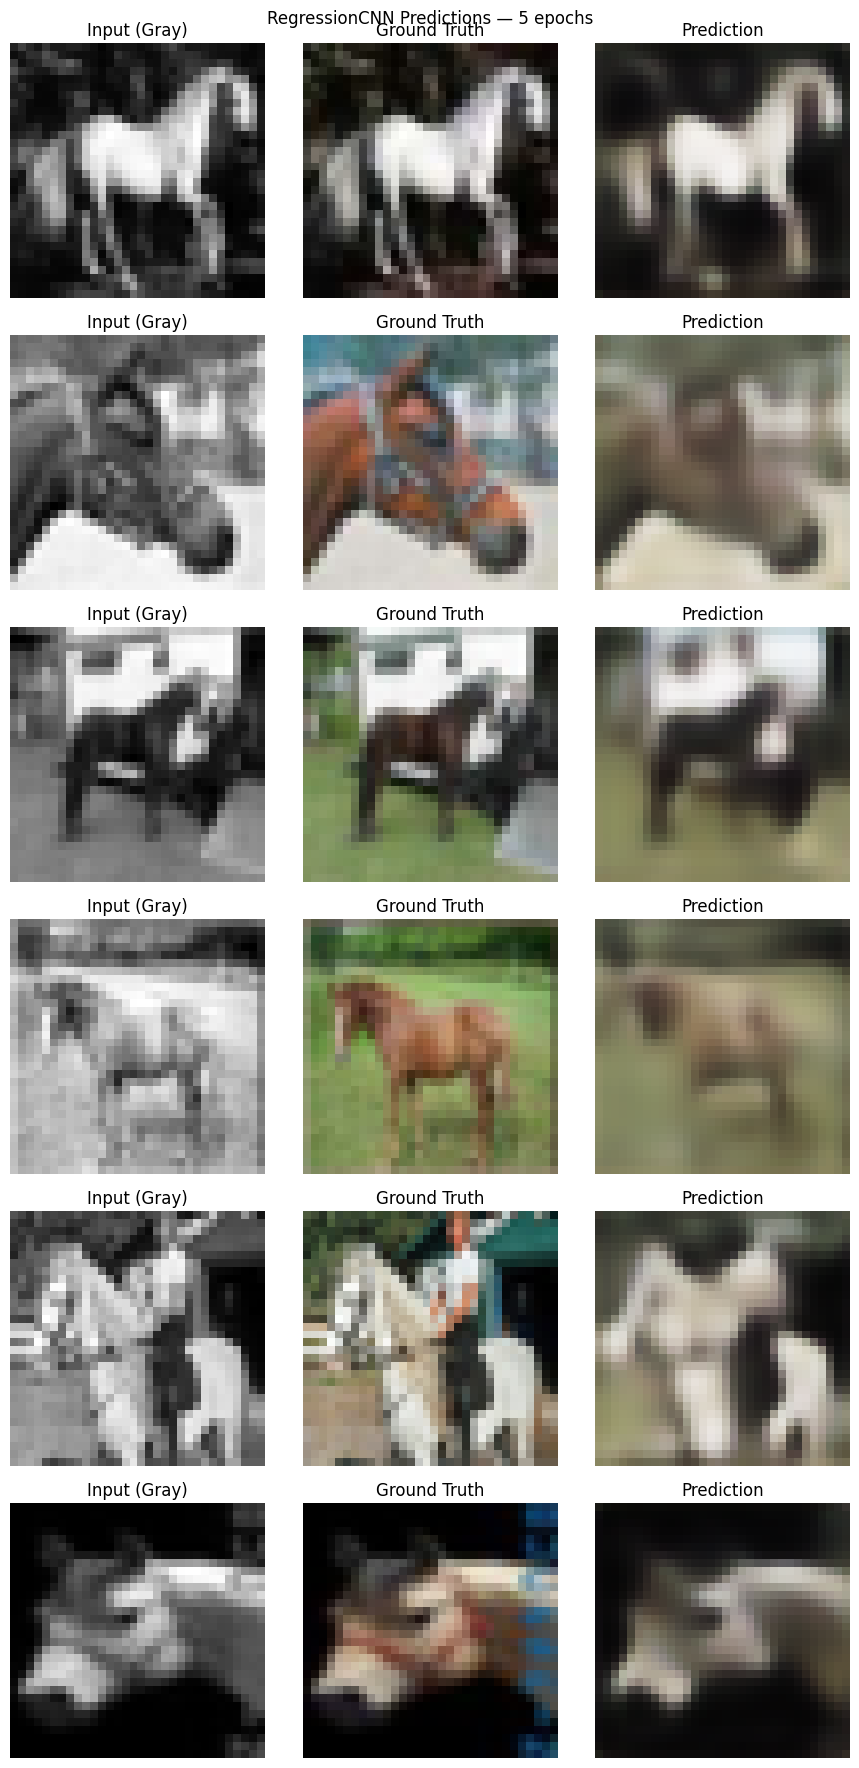

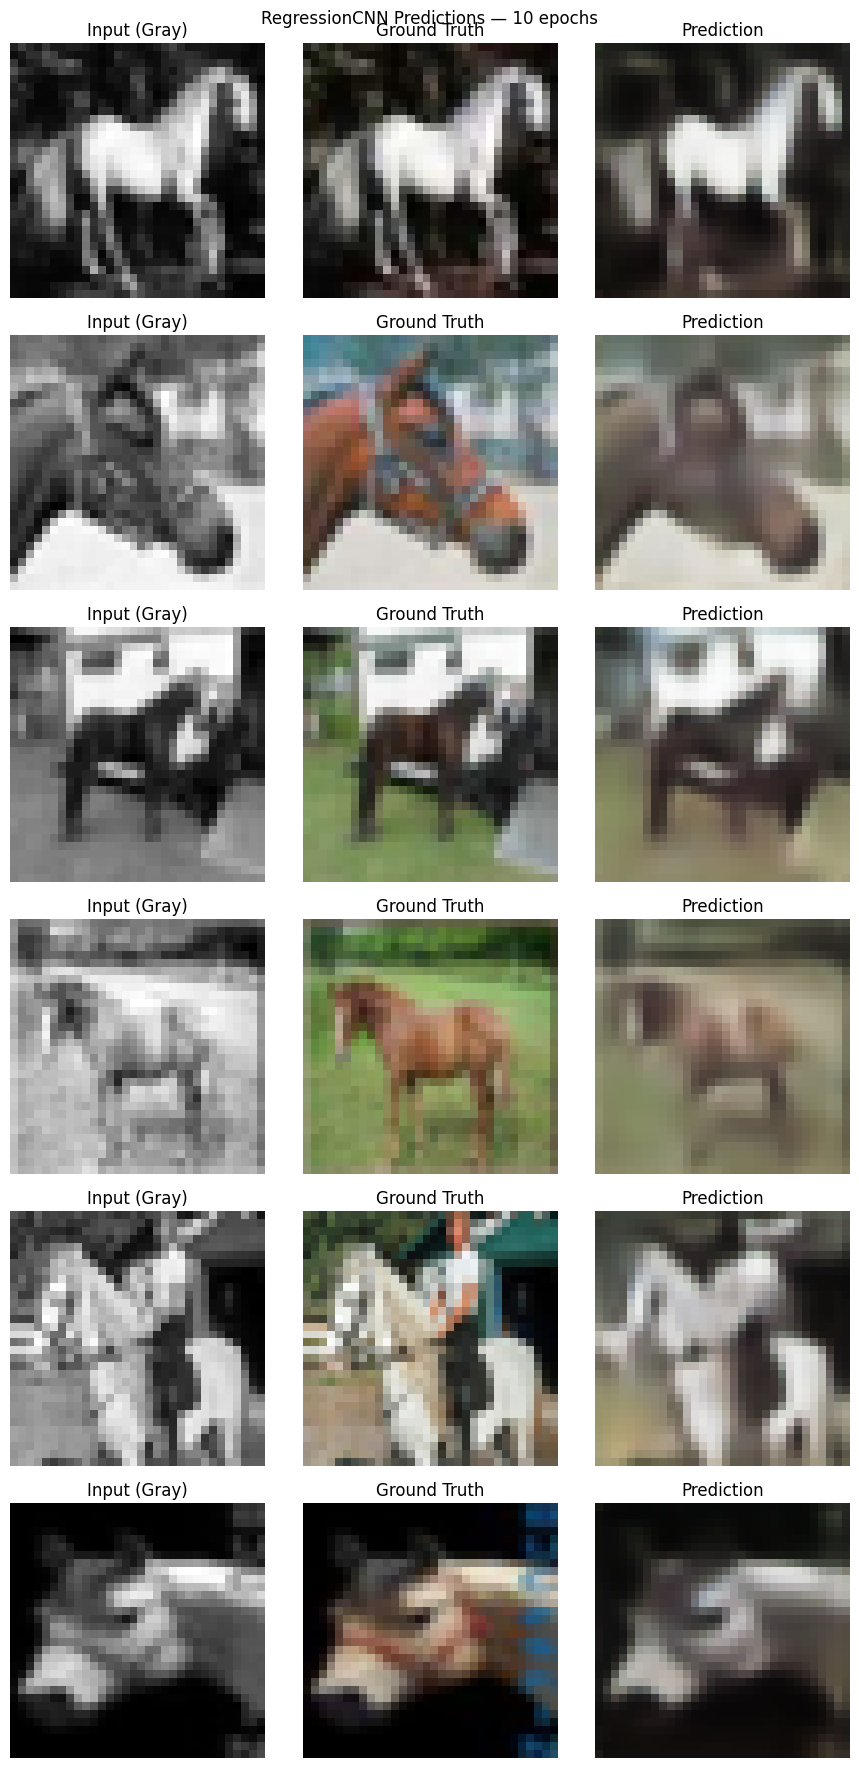

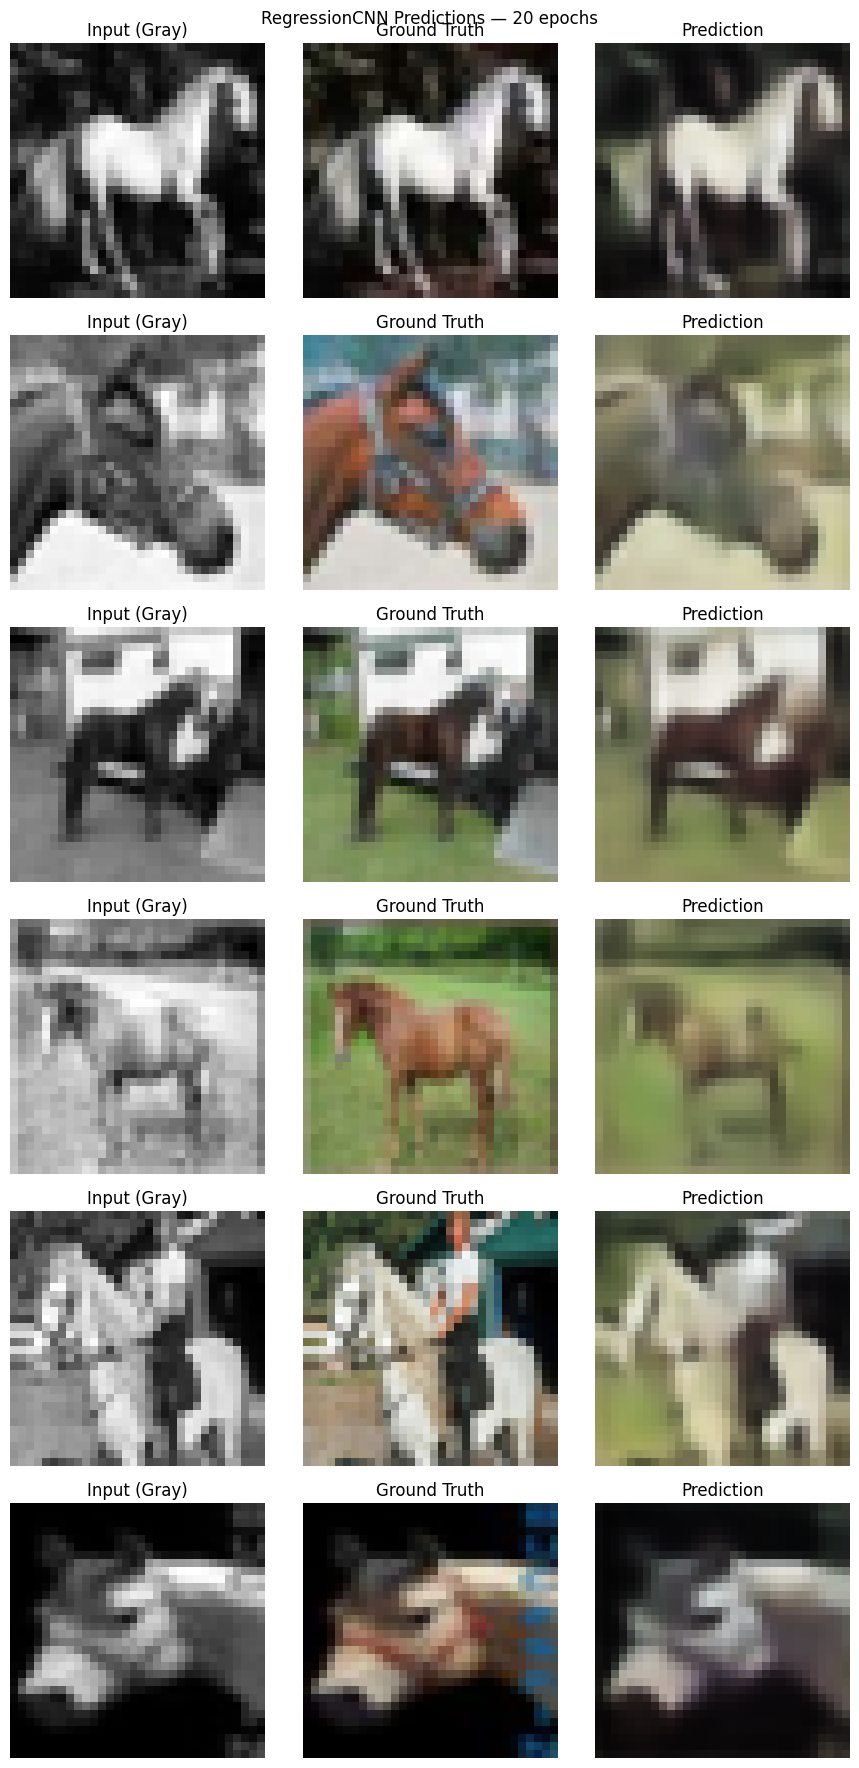

In [ ]:
for epochs, result in regression_results.items():
    samples = collect_samples(result['model'], test_loader, mode='regression', max_items=min(cfg.num_vis_samples, 6))
    show_colorization_triplets(samples, title=f'RegressionCNN Predictions — {epochs} epochs')


Epoch 1/20 | Train Loss: 2.5222 | Val Loss: 2.3026
Epoch 2/20 | Train Loss: 2.0901 | Val Loss: 2.0729
Epoch 3/20 | Train Loss: 1.9174 | Val Loss: 1.8569
Epoch 4/20 | Train Loss: 1.8352 | Val Loss: 1.8352
Epoch 5/20 | Train Loss: 1.7453 | Val Loss: 1.7972
Epoch 6/20 | Train Loss: 1.7211 | Val Loss: 1.7241
Epoch 7/20 | Train Loss: 1.6775 | Val Loss: 1.7939
Epoch 8/20 | Train Loss: 1.6115 | Val Loss: 1.6326
Epoch 9/20 | Train Loss: 1.5952 | Val Loss: 1.6402
Epoch 10/20 | Train Loss: 1.5911 | Val Loss: 1.7357
Epoch 11/20 | Train Loss: 1.5220 | Val Loss: 1.6446
Epoch 12/20 | Train Loss: 1.5236 | Val Loss: 1.6099
Epoch 13/20 | Train Loss: 1.4732 | Val Loss: 1.7095
Epoch 14/20 | Train Loss: 1.4435 | Val Loss: 1.6826
Epoch 15/20 | Train Loss: 1.4057 | Val Loss: 1.7988
Epoch 16/20 | Train Loss: 1.4053 | Val Loss: 2.0307
Epoch 17/20 | Train Loss: 1.3553 | Val Loss: 1.7546
Epoch 18/20 | Train Loss: 1.3059 | Val Loss: 1.6172
Epoch 19/20 | Train Loss: 1.3013 | Val Loss: 1.8066
Epoch 20/20 | Train L

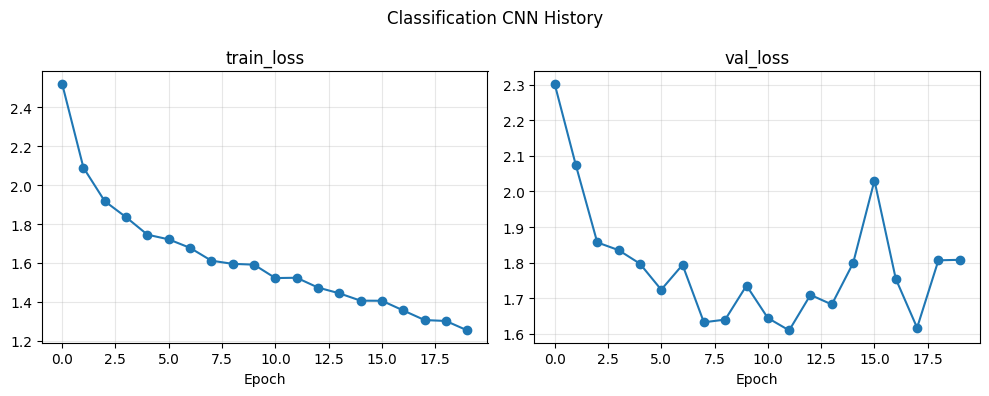

In [ ]:
cls_model = PixelClassificationCNN(num_bins=cfg.num_color_bins)
cls_model, cls_history = train_one_model(
    model=cls_model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode='classification',
    epochs=cfg.classification_epochs,
    device=device,
    centers=color_centers,
    tag='classification_cnn'
)

cls_val_stats = evaluate_classification(cls_model, val_loader, device, color_centers)
cls_test_stats = evaluate_classification(cls_model, test_loader, device, color_centers)

print('Classification CNN | VAL :', cls_val_stats)
print('Classification CNN | TEST:', cls_test_stats)
plot_history(cls_history, title='Classification CNN History')


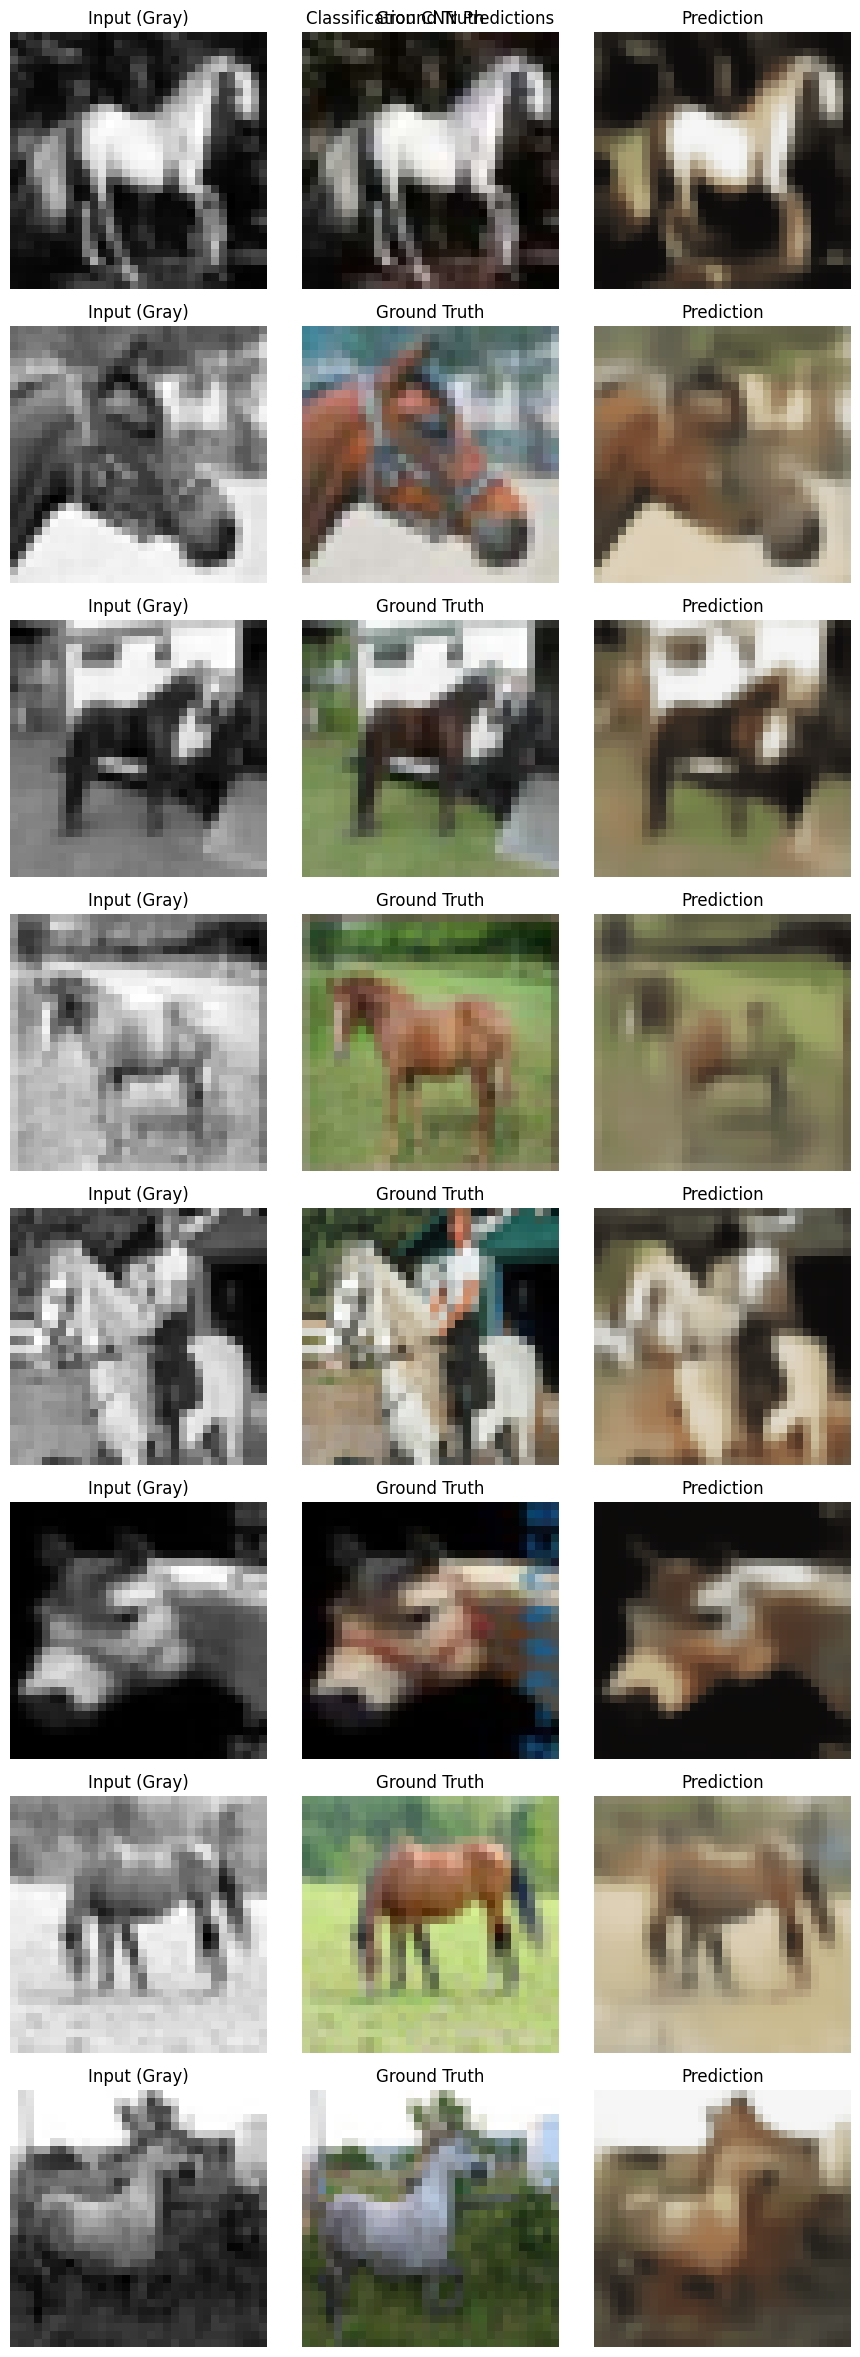

In [ ]:
cls_samples = collect_samples(cls_model, test_loader, mode='classification', centers=color_centers, max_items=min(cfg.num_vis_samples, 8))
show_colorization_triplets(cls_samples, title='Classification CNN Predictions')


Epoch 1/20 | Train Loss: 2.3027 | Val Loss: 2.2561
Epoch 2/20 | Train Loss: 1.6695 | Val Loss: 1.5151
Epoch 3/20 | Train Loss: 1.4338 | Val Loss: 1.3335
Epoch 4/20 | Train Loss: 1.3195 | Val Loss: 1.4106
Epoch 5/20 | Train Loss: 1.2468 | Val Loss: 1.1980
Epoch 6/20 | Train Loss: 1.2152 | Val Loss: 1.1566
Epoch 7/20 | Train Loss: 1.1748 | Val Loss: 1.1205
Epoch 8/20 | Train Loss: 1.1343 | Val Loss: 1.0808
Epoch 9/20 | Train Loss: 1.1371 | Val Loss: 1.1238
Epoch 10/20 | Train Loss: 1.1413 | Val Loss: 1.0831
Epoch 11/20 | Train Loss: 1.1166 | Val Loss: 1.1143
Epoch 12/20 | Train Loss: 1.1423 | Val Loss: 1.1209
Epoch 13/20 | Train Loss: 1.1405 | Val Loss: 1.0572
Epoch 14/20 | Train Loss: 1.1007 | Val Loss: 1.0824
Epoch 15/20 | Train Loss: 1.0566 | Val Loss: 1.0679
Epoch 16/20 | Train Loss: 1.0340 | Val Loss: 1.0690
Epoch 17/20 | Train Loss: 1.0021 | Val Loss: 1.0898
Epoch 18/20 | Train Loss: 1.0260 | Val Loss: 1.0906
Epoch 19/20 | Train Loss: 1.0264 | Val Loss: 1.1097
Epoch 20/20 | Train L

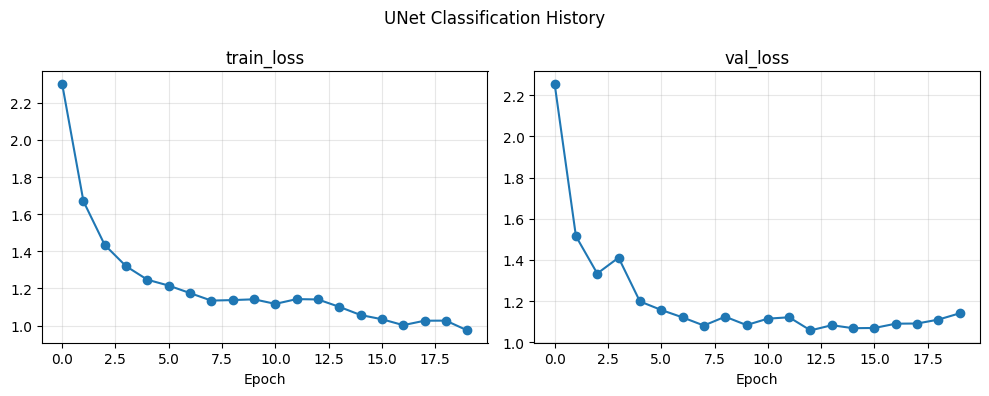

In [ ]:
unet_model = UNetPixelClassifier(num_bins=cfg.num_color_bins)
unet_model, unet_history = train_one_model(
    model=unet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode='classification',
    epochs=cfg.unet_epochs,
    device=device,
    centers=color_centers,
    tag='unet_classifier'
)

unet_val_stats = evaluate_classification(unet_model, val_loader, device, color_centers)
unet_test_stats = evaluate_classification(unet_model, test_loader, device, color_centers)

print('UNet | VAL :', unet_val_stats)
print('UNet | TEST:', unet_test_stats)
plot_history(unet_history, title='UNet Classification History')


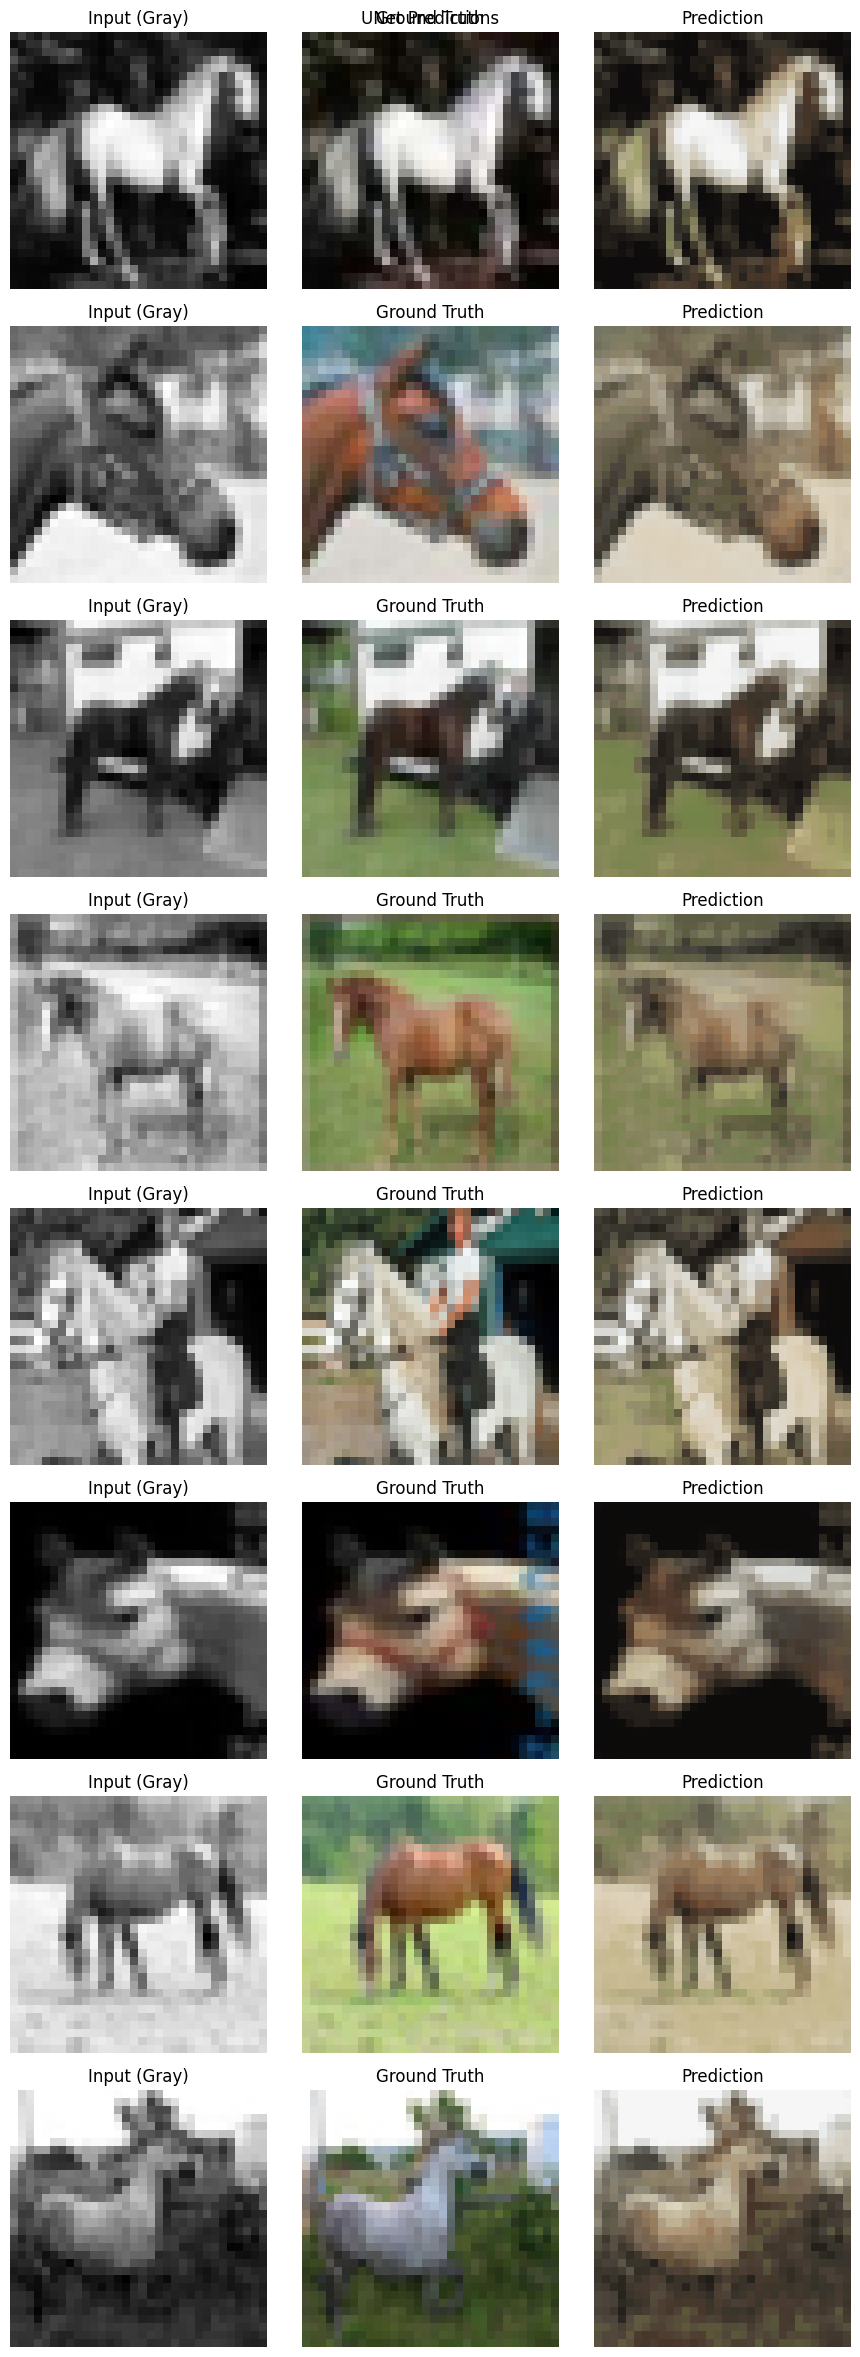

In [ ]:
unet_samples = collect_samples(unet_model, test_loader, mode='classification', centers=color_centers, max_items=min(cfg.num_vis_samples, 8))
show_colorization_triplets(unet_samples, title='UNet Predictions')


In [ ]:
best_reg_epochs = min(regression_results.keys(), key=lambda e: regression_results[e]['val_stats']['loss'])
best_reg = regression_results[best_reg_epochs]

summary = {
    'best_regression_epochs': best_reg_epochs,
    'best_regression_val': best_reg['val_stats'],
    'best_regression_test': best_reg['test_stats'],
    'classification_val': cls_val_stats,
    'classification_test': cls_test_stats,
    'unet_val': unet_val_stats,
    'unet_test': unet_test_stats,
}

print(json.dumps(summary, indent=2))


{
  "best_regression_epochs": 10,
  "best_regression_val": {
    "loss": 0.0062152879312634465
  },
  "best_regression_test": {
    "loss": 0.006345843197777867
  },
  "classification_val": {
    "loss": 1.8080033302307128
  },
  "classification_test": {
    "loss": 1.8431748509407044
  },
  "unet_val": {
    "loss": 1.140299654006958
  },
  "unet_test": {
    "loss": 1.1445401310920715
  }
}


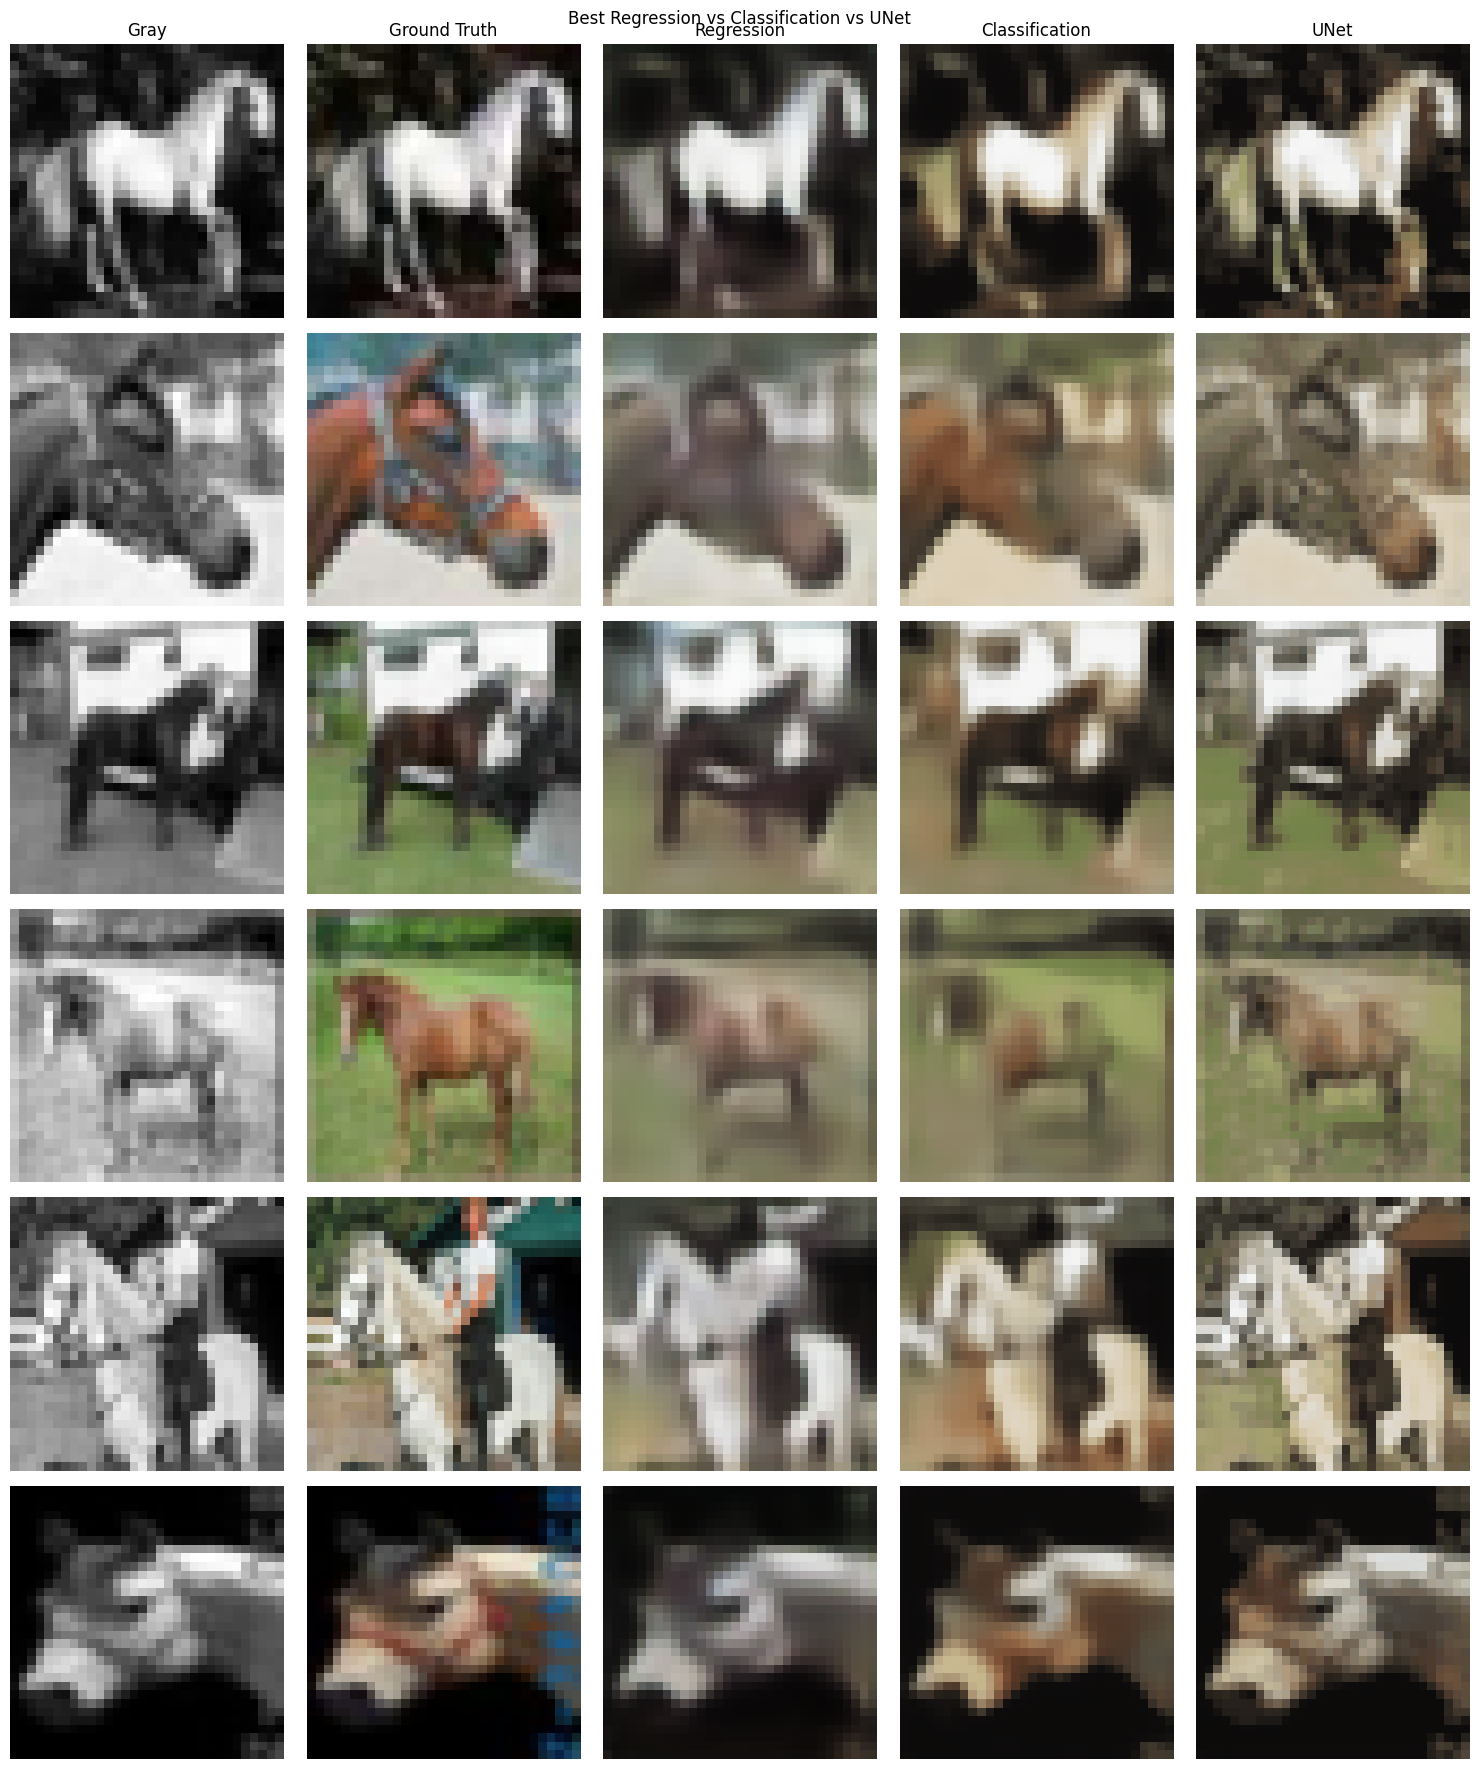

In [ ]:
@torch.no_grad()
def gather_same_batch_outputs(reg_model, cls_model, unet_model, loader, centers, n=6):
    batch = next(iter(loader))
    gray = batch['gray'][:n].to(device)
    gt = batch['rgb'][:n].cpu()

    reg_pred = reg_model(gray).cpu()
    cls_pred = logits_to_rgb(cls_model(gray), centers.to(device)).cpu()
    unet_pred = logits_to_rgb(unet_model(gray), centers.to(device)).cpu()
    gray_cpu = gray.cpu()
    return gray_cpu, gt, reg_pred, cls_pred, unet_pred


def show_comparison_panel(gray, gt, reg_pred, cls_pred, unet_pred, title='Model Comparison'):
    n = gray.size(0)
    fig, axes = plt.subplots(n, 5, figsize=(15, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    col_titles = ['Gray', 'Ground Truth', 'Regression', 'Classification', 'UNet']
    for c, t in enumerate(col_titles):
        axes[0, c].set_title(t)
    for i in range(n):
        axes[i, 0].imshow(gray[i, 0], cmap='gray')
        axes[i, 1].imshow(gt[i].permute(1, 2, 0).clamp(0, 1))
        axes[i, 2].imshow(reg_pred[i].permute(1, 2, 0).clamp(0, 1))
        axes[i, 3].imshow(cls_pred[i].permute(1, 2, 0).clamp(0, 1))
        axes[i, 4].imshow(unet_pred[i].permute(1, 2, 0).clamp(0, 1))
        for j in range(5):
            axes[i, j].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

gray, gt, reg_pred, cls_pred, unet_pred = gather_same_batch_outputs(
    best_reg['model'], cls_model, unet_model, test_loader, color_centers, n=min(cfg.num_vis_samples, 6)
)
show_comparison_panel(gray, gt, reg_pred, cls_pred, unet_pred, title='Best Regression vs Classification vs UNet')


In [ ]:
def register_activation_hooks(model: nn.Module, layer_names: List[str]):
    activations = {}
    hooks = []

    name_to_module = dict(model.named_modules())
    for name in layer_names:
        if name not in name_to_module:
            print(f'Layer not found: {name}')
            continue
        module = name_to_module[name]
        def _make_hook(key):
            def hook(mod, inp, out):
                activations[key] = out.detach().cpu()
            return hook
        hooks.append(module.register_forward_hook(_make_hook(name)))
    return activations, hooks


def show_activation_maps(activation_tensor: torch.Tensor, title: str, max_maps: int = 8):
    fmap = activation_tensor[0]
    num_maps = min(max_maps, fmap.size(0))
    cols = 4
    rows = math.ceil(num_maps / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(rows, cols)
    for i in range(rows * cols):
        ax = axes.flat[i]
        if i < num_maps:
            ax.imshow(fmap[i], cmap='viridis')
            ax.set_title(f'Channel {i}')
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


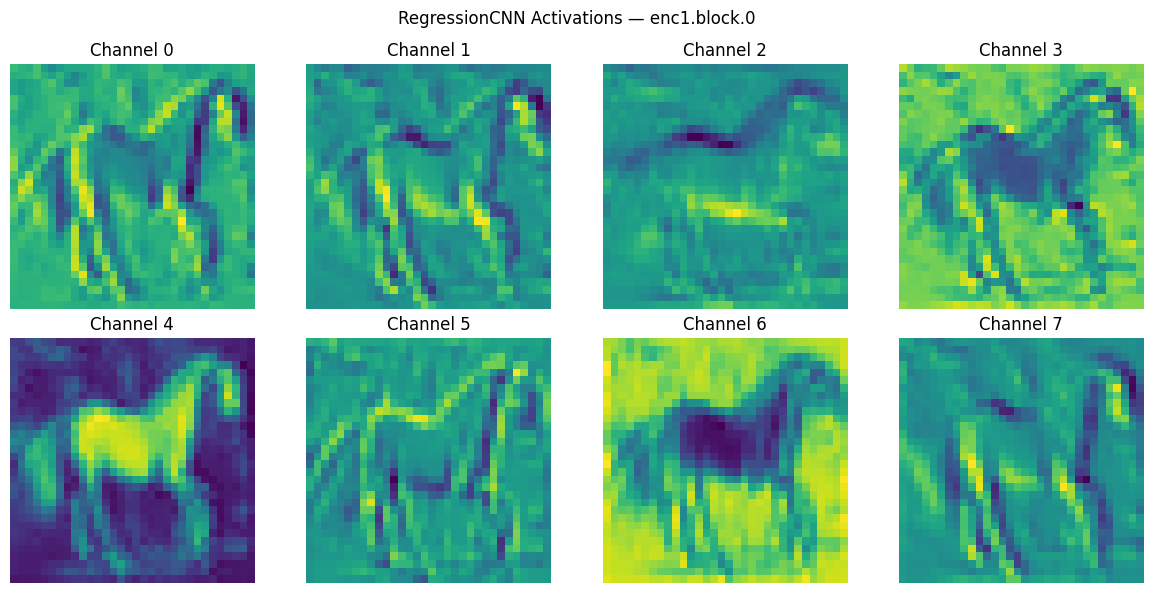

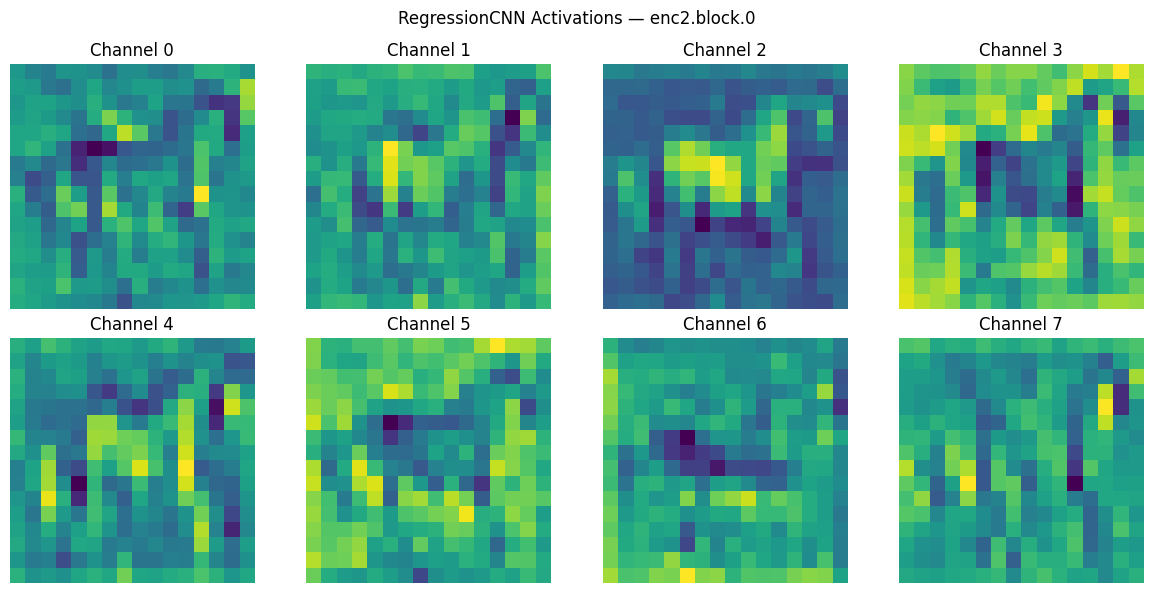

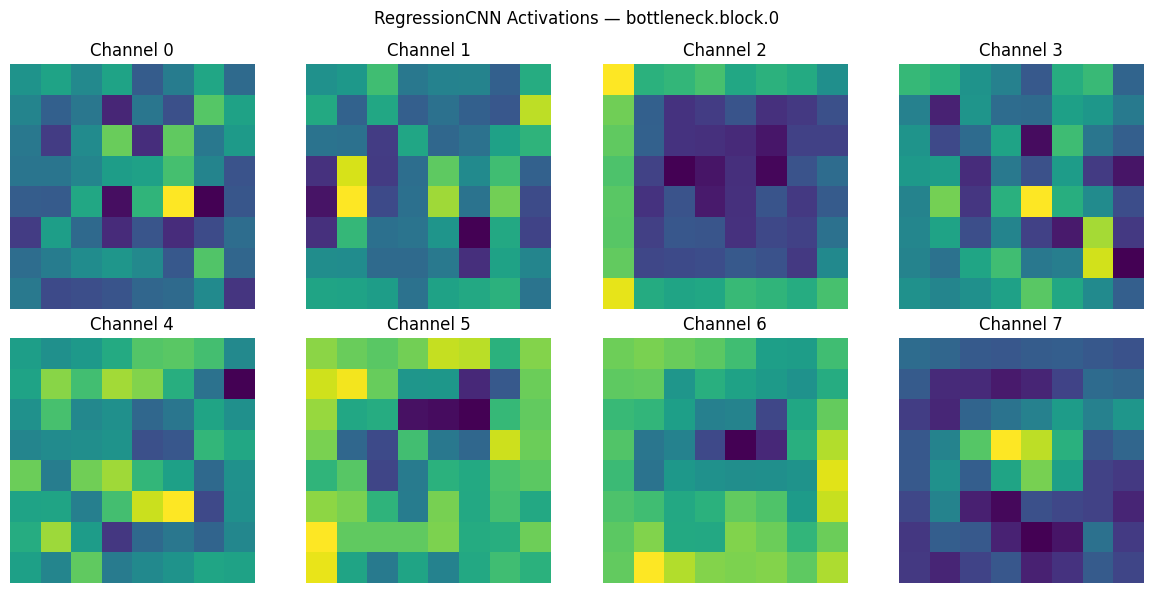

In [ ]:
reg_layers = ['enc1.block.0', 'enc2.block.0', 'bottleneck.block.0']
reg_acts, reg_hooks = register_activation_hooks(best_reg['model'], reg_layers)

sample_batch = next(iter(test_loader))
sample_gray = sample_batch['gray'][:1].to(device)
_ = best_reg['model'](sample_gray)

for name in reg_layers:
    if name in reg_acts:
        show_activation_maps(reg_acts[name], title=f'RegressionCNN Activations — {name}', max_maps=cfg.activation_maps_to_show)

for h in reg_hooks:
    h.remove()


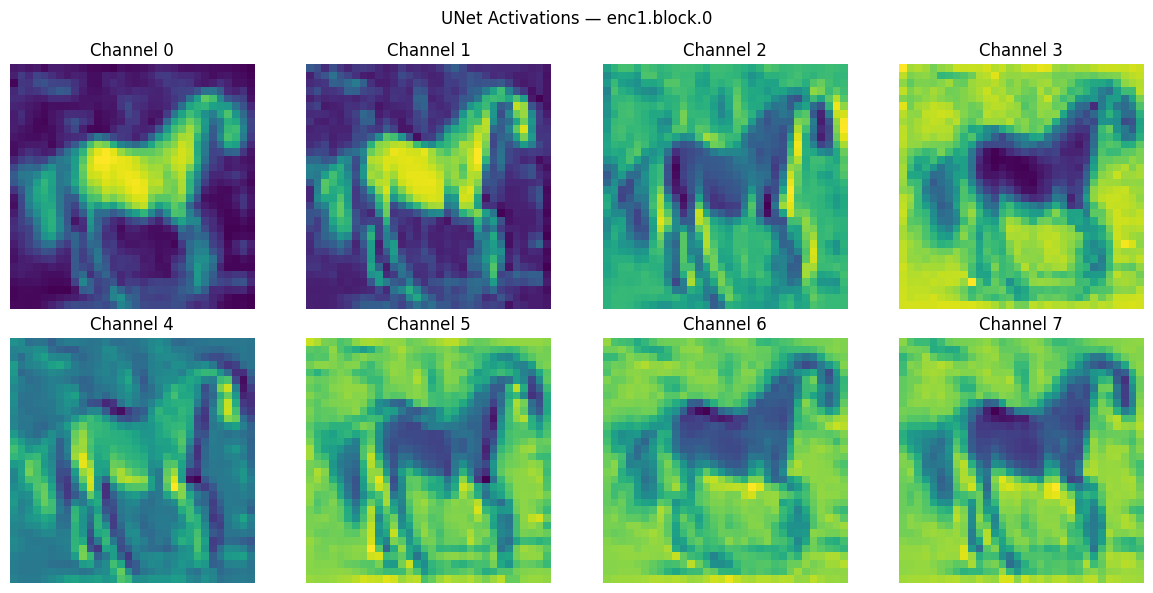

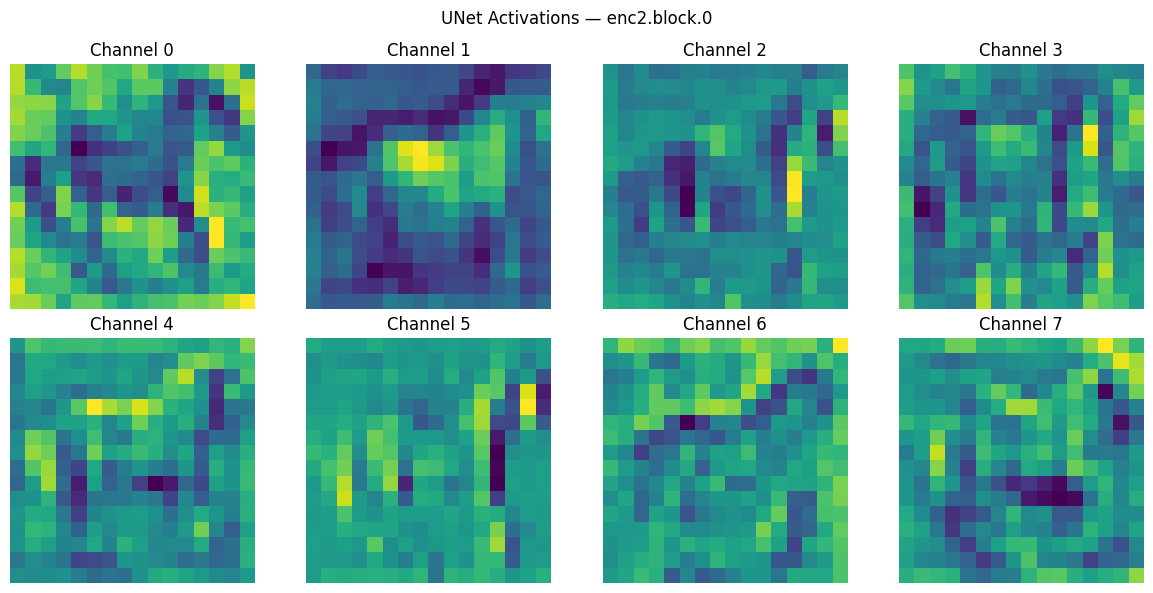

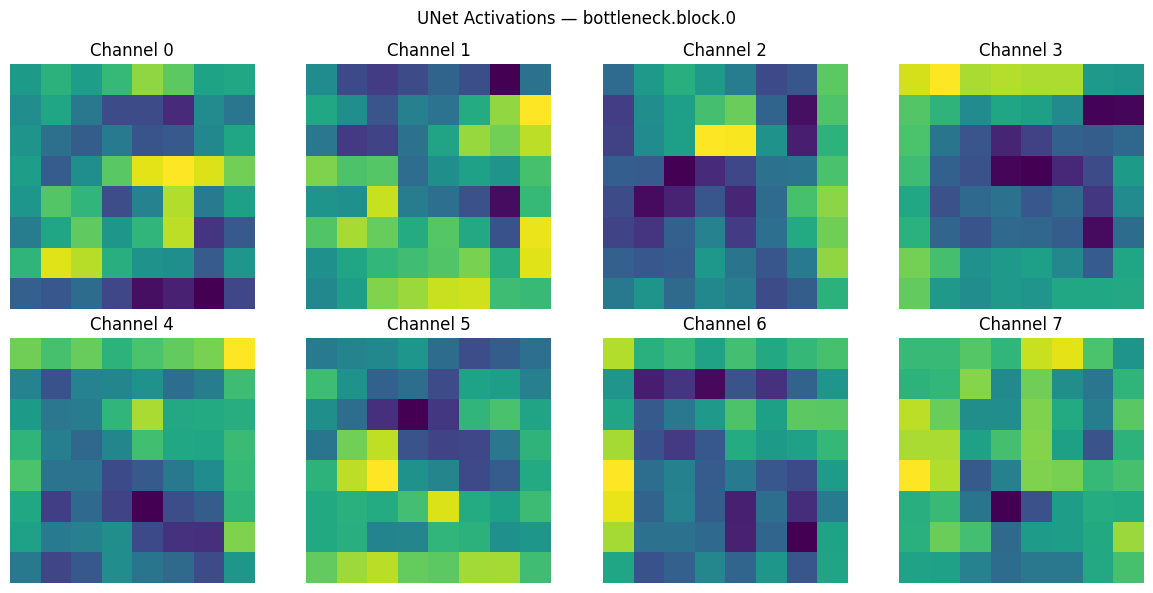

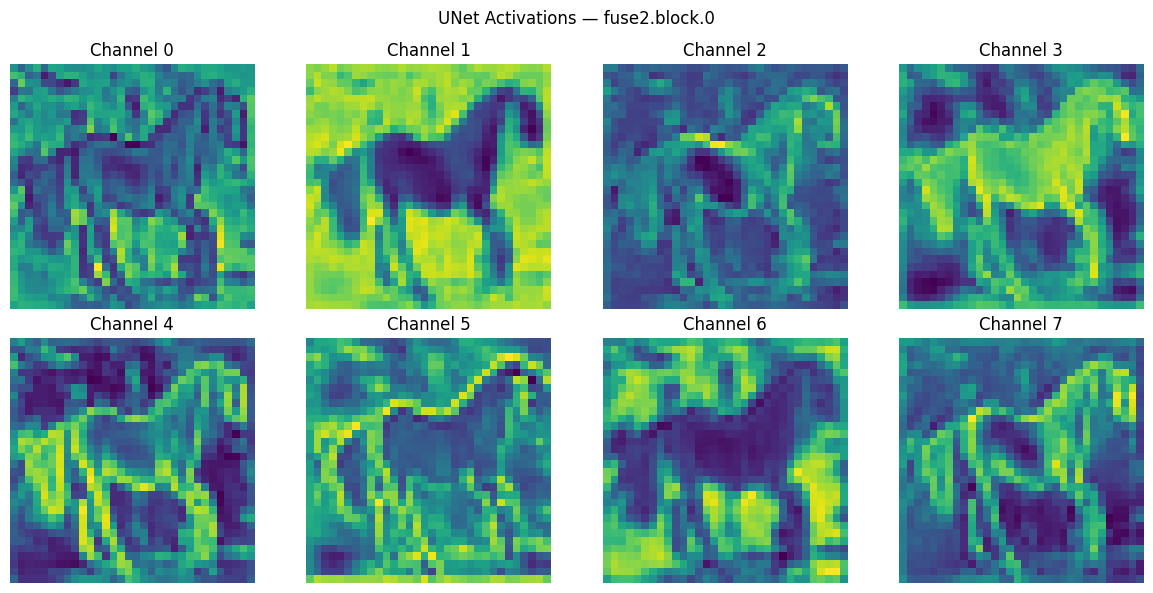

In [ ]:
unet_layers = ['enc1.block.0', 'enc2.block.0', 'bottleneck.block.0', 'fuse2.block.0']
unet_acts, unet_hooks = register_activation_hooks(unet_model, unet_layers)

_ = unet_model(sample_gray)
for name in unet_layers:
    if name in unet_acts:
        show_activation_maps(unet_acts[name], title=f'UNet Activations — {name}', max_maps=cfg.activation_maps_to_show)

for h in unet_hooks:
    h.remove()


In [ ]:
from PIL import Image

@torch.no_grad()
def colorize_external_image(image_path: str, model: nn.Module, mode: str, centers: Optional[torch.Tensor] = None,
                            resize_to: Optional[Tuple[int, int]] = None):
    img = Image.open(image_path).convert('RGB')
    if resize_to is not None:
        img = img.resize(resize_to)
    img_np = np.array(img).astype(np.float32) / 255.0
    rgb = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0)
    gray = rgb_to_gray_batch(rgb)

    model.eval()
    gray_dev = gray.to(device)
    if mode == 'regression':
        pred = model(gray_dev).cpu()[0]
    else:
        logits = model(gray_dev)
        pred = logits_to_rgb(logits, centers.to(device)).cpu()[0]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(gray[0, 0], cmap='gray')
    axes[0].set_title('Input Grayscale')
    axes[1].imshow(rgb[0].permute(1, 2, 0).clamp(0, 1))
    axes[1].set_title('Reference RGB (if available)')
    axes[2].imshow(pred.permute(1, 2, 0).clamp(0, 1))
    axes[2].set_title('Predicted Colorization')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage (upload an image to Colab first):
# colorize_external_image('my_image.jpg', unet_model, mode='classification', centers=color_centers)


In [ ]:
summary_path = Path(cfg.work_dir) / 'summary_metrics.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved summary to:', summary_path)


Saved summary to: assignment3_outputs/summary_metrics.json
